In [40]:
import pandas as pd

df = pd.read_csv("../data/cleaned_superstore.csv")

print(df.head())
print(df.shape)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  US-2023-103800  2023-01-03  2023-01-07  Standard Class    DP-13000   
1       2  US-2023-112326  2023-01-04  2023-01-08  Standard Class    PO-19195   
2       3  US-2023-112326  2023-01-04  2023-01-08  Standard Class    PO-19195   
3       4  US-2023-112326  2023-01-04  2023-01-08  Standard Class    PO-19195   
4       5  US-2023-141817  2023-01-05  2023-01-12  Standard Class    MB-18085   

   Customer Name      Segment Country/Region          City  ... Postal Code  \
0  Darren Powers     Consumer  United States       Houston  ...       77095   
1  Phillina Ober  Home Office  United States    Naperville  ...       60540   
2  Phillina Ober  Home Office  United States    Naperville  ...       60540   
3  Phillina Ober  Home Office  United States    Naperville  ...       60540   
4     Mick Brown     Consumer  United States  Philadelphia  ...       19143   

    Region       Product ID         Ca

In [41]:
print("Mean")
print(df[['Sales','Profit','Quantity']].mean())

print("\nMedian")
print(df[['Sales','Profit','Quantity']].median())

print("\nMode")
print(df[['Sales','Profit','Quantity']].mode())

print("\nStandard Deviation")
print(df[['Sales','Profit','Quantity']].std())

Mean
Sales       228.225854
Profit       28.673417
Quantity      3.791838
dtype: float64

Median
Sales       53.91
Profit       8.69
Quantity     3.00
dtype: float64

Mode
   Sales  Profit  Quantity
0  12.96     0.0         2

Standard Deviation
Sales       619.906839
Profit      232.465115
Quantity      2.228317
dtype: float64


In [42]:
df[['Sales','Profit','Quantity']].describe()

,Sales,Profit,Quantity
count,10194.000000,10194.000000,10194.000000
mean,228.225854,28.673417,3.791838
std,619.906839,232.465115,2.228317
min,0.444000,-6599.978000,1.000000
25%,17.220000,1.760800,2.000000
50%,53.910000,8.690000,3.000000
75%,209.500000,29.297925,5.000000
max,22638.480000,8399.976000,14.000000


In [43]:
from scipy.stats import ttest_ind

furniture = df[df['Category']=='Furniture']['Sales']
technology = df[df['Category']=='Technology']['Sales']

t_stat, p_value = ttest_ind(furniture, technology)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -4.101142672958094
P-Value: 4.1915932784479277e-05


In [44]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['Sales','Profit','Quantity']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

Cluster
0    6958
3    3020
2     206
1      10
Name: count, dtype: int64


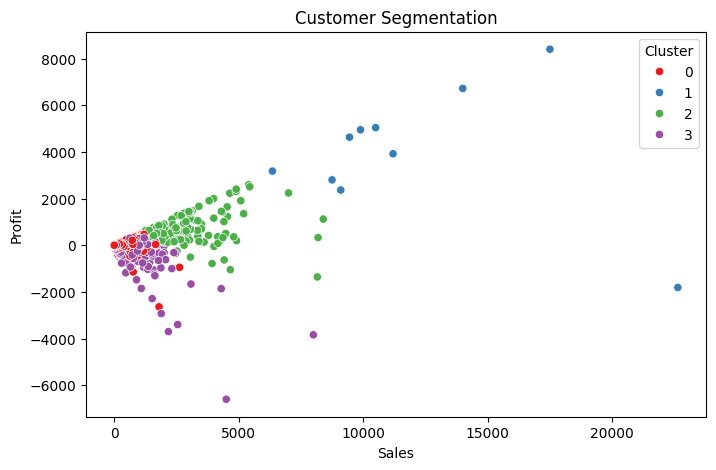

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['Quantity']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))

R2 Score: 0.03449764366647279


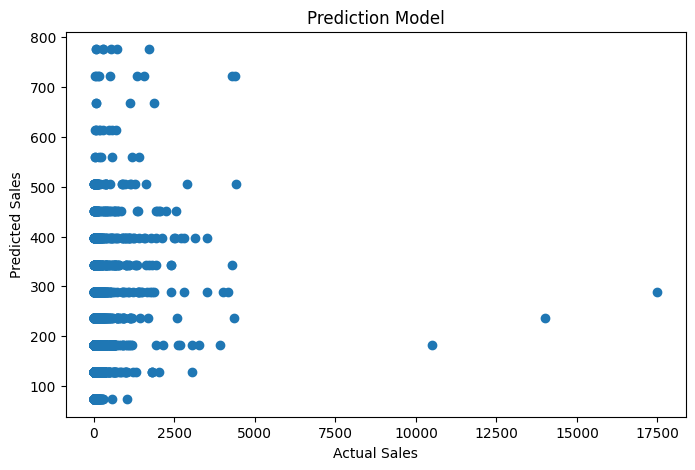

In [47]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Prediction Model")

plt.show()

# Task 4 Insights

1. The average sales and profit values were calculated using statistical analysis.
2. Technology and Furniture categories show significant differences in sales.
3. Customer segmentation grouped customers into 4 clusters based on sales, profit, and quantity.
4. Cluster analysis identified different customer behavior patterns.
5. A linear regression model was built to predict sales using quantity.
6. The prediction model provides insights into future sales trends.